# 📊 Notebook 03 — Visualisation des Données Traitées (Processed Data)

**Objectif :** Inspecter et visualiser les 4 tables finales générées dans le dossier `data/processed` :
1. `commandes_clean.csv` — En-têtes de factures nettoyées
2. `lignes_clean.csv` — Lignes de commandes nettoyées (avec catégories corrigées)
3. `gps_clean.csv` — Coordonnées GPS des clients nettoyées
4. `feature_matrix.csv` — Matrice de Feature Engineering (Client × Article) pour le Machine Learning

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Style visuel sombre pour des graphiques premium
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#2e3250',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#c9d1d9',
    'ytick.color':      '#c9d1d9',
    'text.color':       '#c9d1d9',
    'grid.color':       '#2e3250',
    'grid.linestyle':   '--',
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   14,
    'axes.labelsize':   11,
})
sns.set_palette(['#7c3aed', '#10b981', '#f59e0b', '#ef4444', '#3b82f6'])

## 📦 1. Chargement des datasets

In [2]:
PROCESSED_DIR = "../data/processed"

print("Chargement des fichiers CSV...")
df_cmd = pd.read_csv(os.path.join(PROCESSED_DIR, "commandes_clean.csv"), parse_dates=["date_commande"])
df_lignes = pd.read_csv(os.path.join(PROCESSED_DIR, "lignes_clean.csv"))
df_gps = pd.read_csv(os.path.join(PROCESSED_DIR, "gps_clean.csv"))
df_features = pd.read_csv(os.path.join(PROCESSED_DIR, "feature_matrix.csv"))

print("\n--- SHAPES DES TABLES ---")
print(f"📁 Commandes (factures) : {df_cmd.shape[0]:,} lignes, {df_cmd.shape[1]} colonnes")
print(f"📁 Lignes de commande   : {df_lignes.shape[0]:,} lignes, {df_lignes.shape[1]} colonnes")
print(f"📁 Clients GPS           : {df_gps.shape[0]:,} lignes, {df_gps.shape[1]} colonnes")
print(f"📁 Feature Matrix        : {df_features.shape[0]:,} lignes, {df_features.shape[1]} colonnes")

Chargement des fichiers CSV...

--- SHAPES DES TABLES ---
📁 Commandes (factures) : 51,784 lignes, 10 colonnes
📁 Lignes de commande   : 199,234 lignes, 7 colonnes
📁 Clients GPS           : 1,057 lignes, 4 colonnes
📁 Feature Matrix        : 105,960 lignes, 29 colonnes


## 📅 2. Analyse des Commandes (`commandes_clean.csv`)

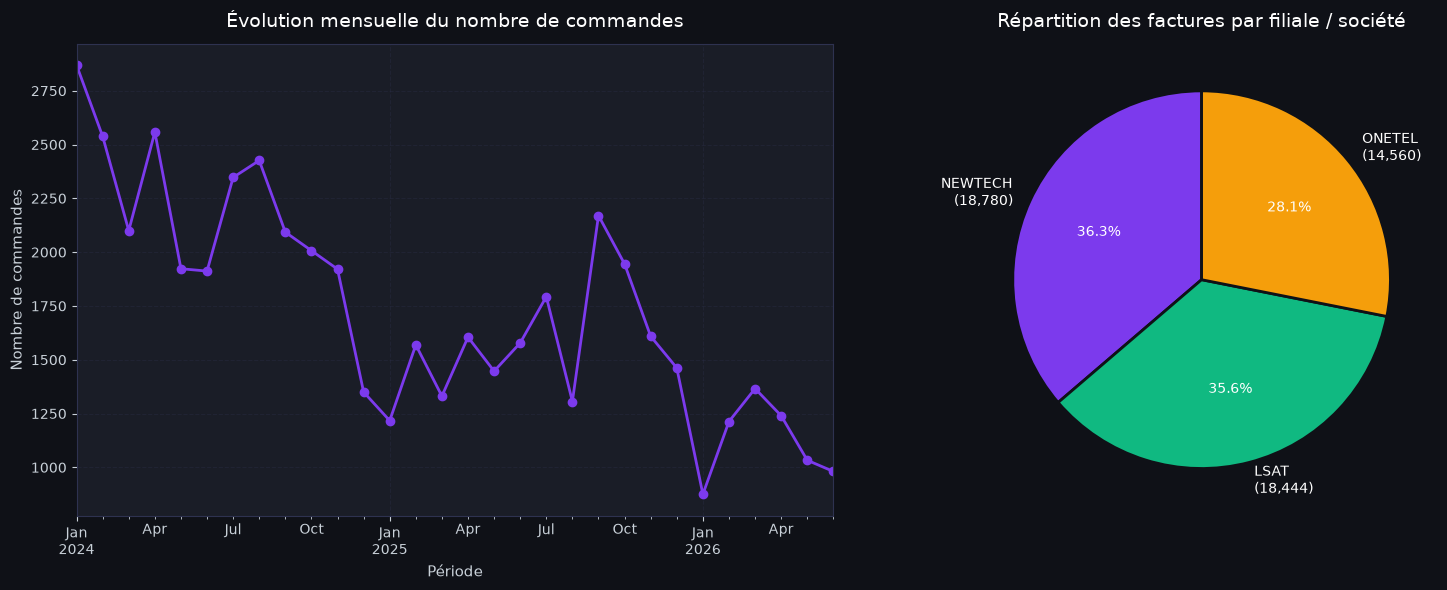

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Nombre de commandes par mois
df_cmd['annee_mois'] = df_cmd['date_commande'].dt.to_period('M')
cmd_par_mois = df_cmd.groupby('annee_mois').size()
cmd_par_mois.plot(kind='line', ax=axes[0], marker='o', color='#7c3aed', linewidth=2)
axes[0].set_title("Évolution mensuelle du nombre de commandes", color='white', pad=12)
axes[0].set_xlabel("Période")
axes[0].set_ylabel("Nombre de commandes")
axes[0].grid(True, alpha=0.3)

# 2. Répartition par société
soc_counts = df_cmd['societe'].value_counts()
axes[1].pie(
    soc_counts.values, 
    labels=[f"{k}\n({v:,})" for k, v in soc_counts.items()], 
    colors=['#7c3aed', '#10b981', '#f59e0b'],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': '#0f1117', 'linewidth': 2},
    textprops={'color': 'white', 'fontsize': 10}
)
axes[1].set_title("Répartition des factures par filiale / société", color='white', pad=12)

plt.tight_layout()
plt.show()

## 🏷️ 3. Analyse des Lignes de Commande (`lignes_clean.csv`)

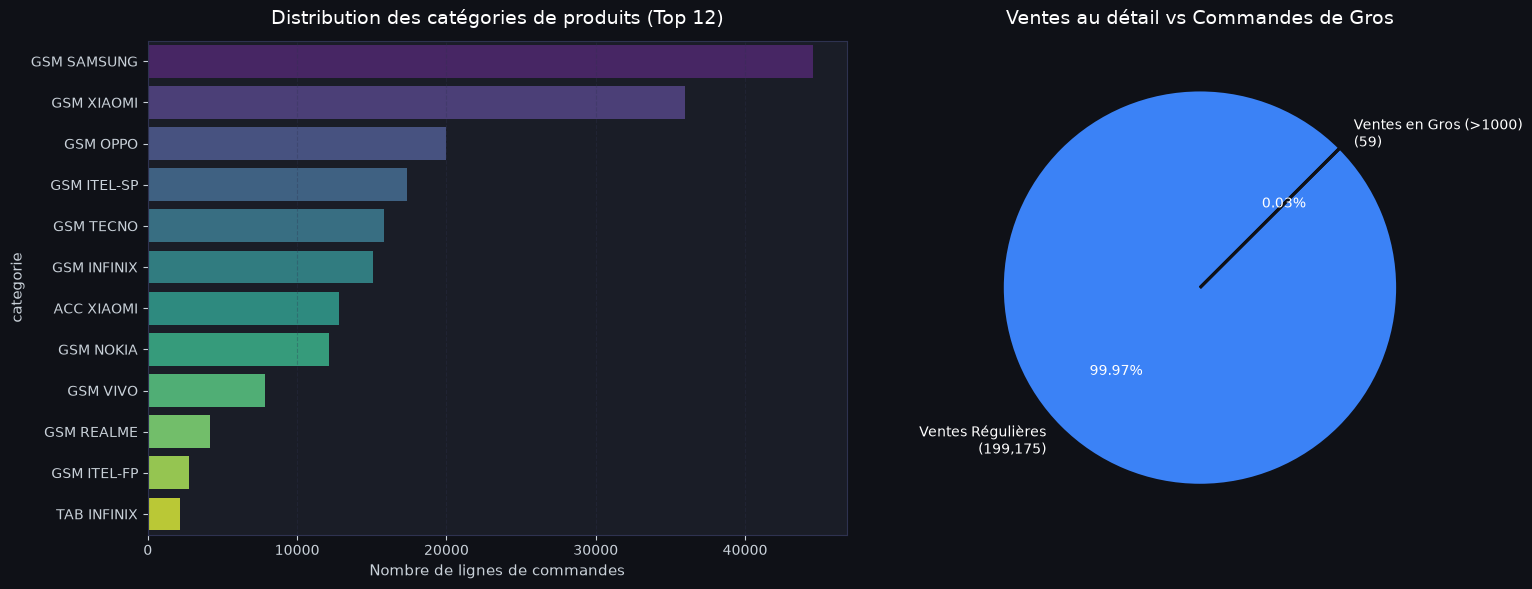

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Distribution des catégories de produits (Top 12)
top_categories = df_lignes['categorie'].value_counts().head(12)
sns.barplot(
    x=top_categories.values, 
    y=top_categories.index, 
    ax=axes[0], 
    palette=sns.color_palette("viridis", len(top_categories)),
    edgecolor='none'
)
axes[0].set_title("Distribution des catégories de produits (Top 12)", color='white', pad=12)
axes[0].set_xlabel("Nombre de lignes de commandes")
axes[0].grid(axis='x', alpha=0.3)

# 2. Ventes régulières vs commandes en gros (Bulk Orders)
bulk_counts = df_lignes['is_bulk_order'].value_counts()
axes[1].pie(
    bulk_counts.values, 
    labels=[f"Ventes Régulières\n({bulk_counts[False]:,})", f"Ventes en Gros (>1000)\n({bulk_counts[True]:,})"],
    colors=['#3b82f6', '#ef4444'],
    autopct='%1.2f%%', startangle=45,
    wedgeprops={'edgecolor': '#0f1117', 'linewidth': 2},
    textprops={'color': 'white', 'fontsize': 10}
)
axes[1].set_title("Ventes au détail vs Commandes de Gros", color='white', pad=12)

plt.tight_layout()
plt.show()

## 🗺️ 4. Géolocalisation des Clients (`gps_clean.csv`)

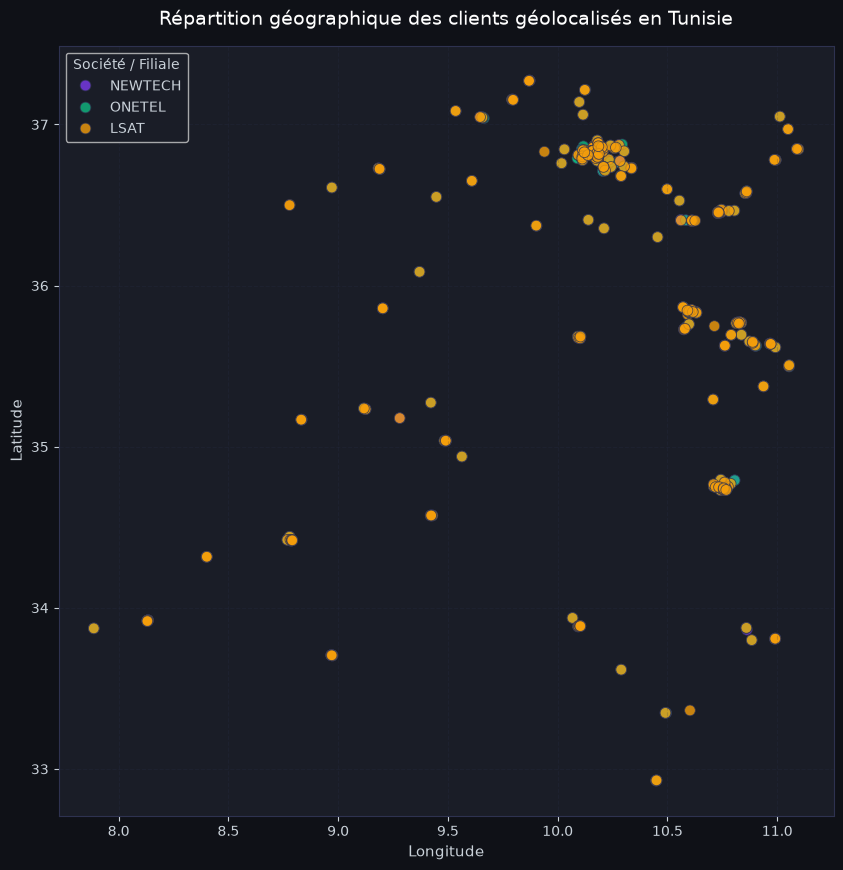

In [5]:
plt.figure(figsize=(10, 10))

# Nuage de points des coordonnées GPS (approximation de la carte tunisienne)
sns.scatterplot(
    data=df_gps, 
    x="longitude", 
    y="latitude", 
    hue="societe", 
    palette=['#7c3aed', '#10b981', '#f59e0b'],
    alpha=0.8, 
    s=60,
    edgecolor='#2e3250'
)

plt.title("Répartition géographique des clients géolocalisés en Tunisie", color='white', pad=15)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True, alpha=0.2)
plt.legend(title="Société / Filiale")
plt.show()

## 🤖 5. Corrélations et Distributions de la Feature Matrix (`feature_matrix.csv`)

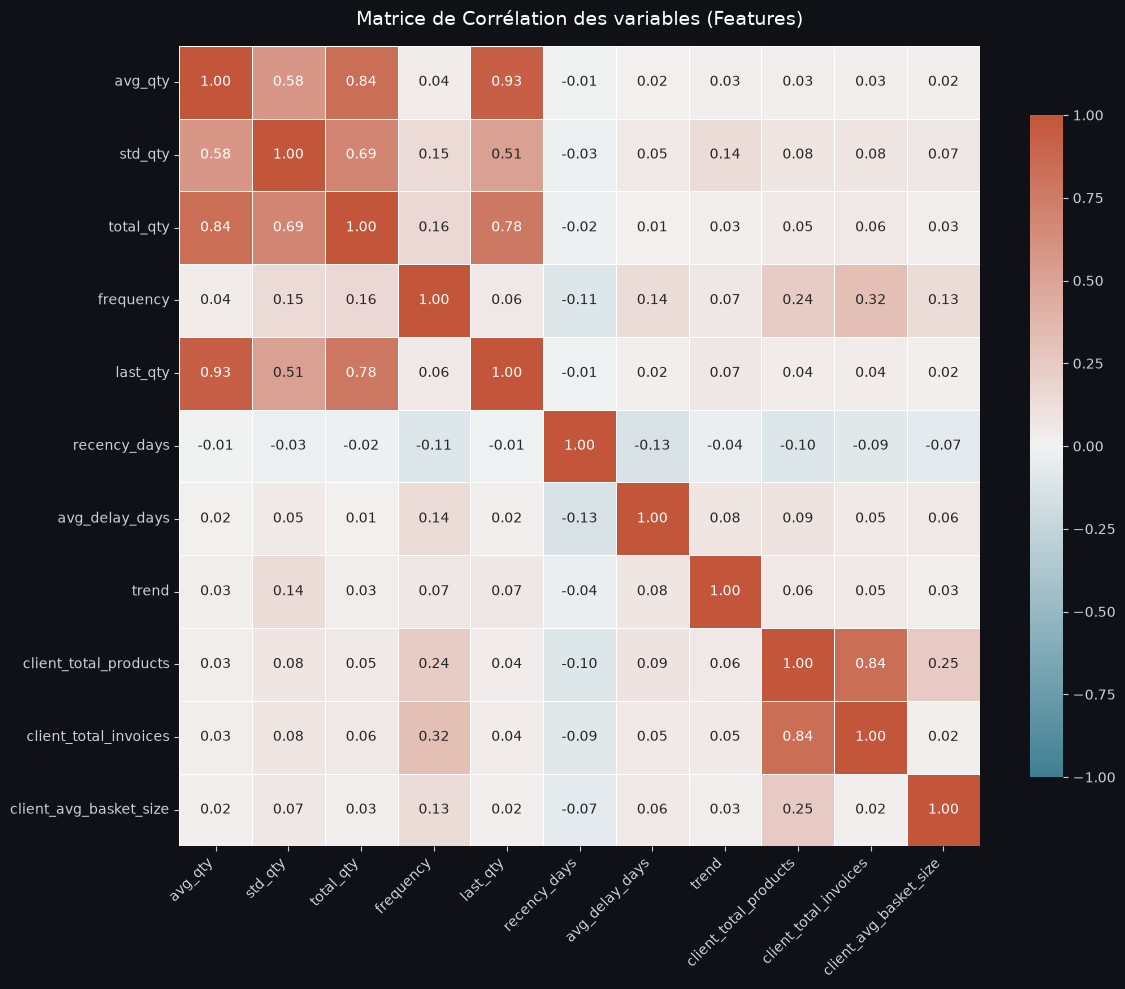

In [6]:
# 1. Matrice de corrélation des caractéristiques quantitatives clés
cols_key_features = [
    "avg_qty", "std_qty", "total_qty", "frequency", 
    "last_qty", "recency_days", "avg_delay_days", "trend",
    "client_total_products", "client_total_invoices", "client_avg_basket_size"
]

corr_matrix = df_features[cols_key_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap=sns.diverging_palette(220, 20, as_cmap=True),
    vmin=-1, 
    vmax=1, 
    square=True, 
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title("Matrice de Corrélation des variables (Features)", color='white', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()